In [1]:
import torch
import torch.nn as nn #오늘의 핵심모듈
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(device)

2.13.0+cu126
cuda


In [ ]:
import torch
import torch.nn as nn
torch.manual_seed(0) # 초기값 재현용
layer = nn.Linear(784,100) # 입력 784, 출력 100 선형 계층
print(layer.weight.shape)#(출력, 입력)
print(layer.bias.shape)
n = sum(p.numel() for p in layer.parameters())
print(n)
x = torch.randn(64,784) # 배치 64
print(layer(x).shape) 

torch.Size([100, 784])
torch.Size([100])
78500
torch.Size([64, 100])


In [ ]:
print(layer.weight[0, :5])
# 0번 뉴런이 가진 가중치 앞 5개
# → tensor([-0.0003, 0.0192, -0.0294, -0.0263, -0.0138], grad_fn=...)
print(layer.bias[0])
# 0번 뉴런의 bias
# → tensor(-0.0354, grad_fn=...)
print(layer.weight.requires_grad)
# 학습으로 갱신되는 파라미터라는 표시
# → True

tensor([-0.0003,  0.0192, -0.0294, -0.0263, -0.0138], grad_fn=<SliceBackward0>)
tensor(-0.0354, grad_fn=<SelectBackward0>)
True


In [4]:
import torch
import torch.nn as nn
layer = nn.Linear(20, 30)
print(sum(p.numel() for p in layer.parameters())) # 1. 20×30 + 30
# → 630
print(layer.weight.shape) # 2. (출력, 입력) 순서
# → torch.Size([30, 20])
print(layer(torch.randn(64, 20)).shape) # 3. 배치는 유지, 특징 20 → 30
# → torch.Size([64, 30])

630
torch.Size([30, 20])
torch.Size([64, 30])


In [19]:
import torch
z = torch.tensor([-100.,-2., -1., 0., 1., 2.,100.])
print(torch.relu(z)) # 음수만 0으로, 양수는 그대로
# → tensor([0., 0., 0., 1., 2.])
print(torch.sigmoid(z)) # 어떤 값이든 0~1 사이로 압축
# → tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])

tensor([  0.,   0.,   0.,   0.,   1.,   2., 100.])
tensor([0.0000, 0.1192, 0.2689, 0.5000, 0.7311, 0.8808, 1.0000])


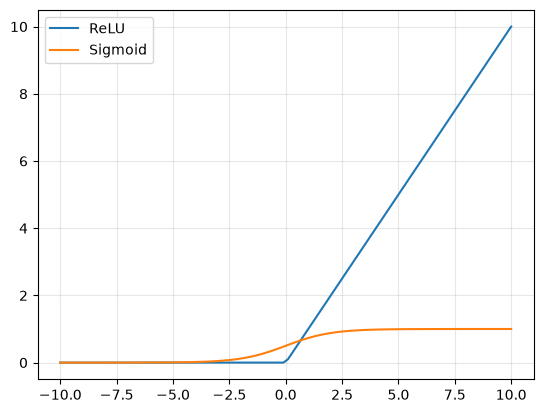

0.0
1.0


In [ ]:
import torch
import matplotlib.pyplot as plt
z = torch.linspace(-10, 10, 100) # 1. -5부터 5까지 100개 점
plt.plot(z, torch.relu(z), label="ReLU")# 2. 두 곡선을 겹쳐 그리기
plt.plot(z, torch.sigmoid(z), label="Sigmoid")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(torch.relu(torch.tensor(-3.7)).item()) #음수는 전부 0 
print(torch.sigmoid(torch.tensor(100.)).item())# 1에 한없이 가까워 1.0으로 출력(1에 수렴)

In [22]:
import torch
import torch.nn as nn
class MLP(nn.Module): # 이 클래스 구조는 표준 틀, 복사해서 시작
    def __init__(self):
        super().__init__() # 틀의 고정 문구
        self.fc1 = nn.Linear(784, 100) # 부품 선언: 은닉 계층
        self.act = nn.ReLU() # 부품 선언: 활성화
        self.fc2 = nn.Linear(100, 10) # 부품 선언: 출력 계층
    def forward(self, x): # 데이터가 흐르는 순서를 정의
     return self.fc2(self.act(self.fc1(x)))
 
torch.manual_seed(0)
model = MLP()
print(sum(p.numel() for p in model.parameters())) # → 79510 (78500 + 1010)
print(model(torch.randn(64, 784)).shape) # → torch.Size([64, 10])



79510
torch.Size([64, 10])


In [26]:
import torch
import torch.nn as nn
class MLP(nn.Module): # 이 클래스 구조는 표준 틀, 복사해서 시작
    def __init__(self):
        super().__init__() # 틀의 고정 문구
        self.fc1 = nn.Linear(784, 256) # 부품 선언: 은닉 계층
        self.act = nn.ReLU() # 부품 선언: 활성화
        self.fc2 = nn.Linear(256, 10) # 부품 선언: 출력 계층
    def forward(self, x): # 데이터가 흐르는 순서를 정의
     return self.fc2(self.act(self.fc1(x)))
 
torch.manual_seed(0)
model = MLP()
print(sum(p.numel() for p in model.parameters())) # 203530 (200960 + 2570)
print(model(torch.randn(8, 784)).shape) # → torch.Size([8, 10])

203530
torch.Size([8, 10])


In [27]:
import torch
import torch.nn as nn
torch.manual_seed(0)
fc1, act, fc2 = nn.Linear(784, 100), nn.ReLU(), nn.Linear(100, 10)
x = torch.randn(64, 784)
h = fc1(x); print(h.shape) # → torch.Size([64, 100])
h = act(h); print(h.shape) # → torch.Size([64, 100])
out = fc2(h); print(out.shape) # → torch.Size([64, 10])
print(out[0].argmax().item()) # 0~9 중 가장 큰 값의 인덱스


torch.Size([64, 100])
torch.Size([64, 100])
torch.Size([64, 10])
3


In [28]:
wrong = nn.Sequential(nn.Linear(100,10), nn.ReLU(), nn.Linear(784,100))
wrong(torch.randn(64, 784))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x784 and 100x10)

In [ ]:
import torch
import torch.nn as nn
layer = nn.Linear(784, 100)
print(layer(torch.randn(32, 784)).shape) # 1. 배치 32도 문제없음
# → torch.Size([32, 100])
# 2. CIFAR-10 컬러 이미지 (3, 32, 32)라면 특징 수 = 3×32×32
print(3 * 32 * 32)
# → 3072 (첫 계층은 nn.Linear(3072, ...)로)
#클래스가 26종이면 마지막 계층의 출력은 26, 출구 규칙 그대로다

torch.Size([32, 100])
3072


In [41]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


device = "cuda" if torch.cuda.is_available() else "cpu"
train_all = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
g = torch.Generator().manual_seed(0)
train_set, val_set = random_split(train_all, [50000, 10000], generator=g)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Linear(784, 10)  # 784 → 10

    def forward(self, x):
        return self.net(x)

# 2주차 파이프라인은 그대로 (train_loader, val_loader)
torch.manual_seed(0)
model = MLP().to(device) # 오늘 직접 구현한 그 클래스
opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader: # 2주차 학습 루프 그대로
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    print(epoch + 1, round(correct / 10000 * 100, 1))
# → (예) 1 89.9
# → (예) 2 93.8
# → (예) 3 94.9 (같은 환경이면 2주차 완성품과 똑같다)

1 87.2
2 88.5
3 89.5


In [49]:
# 한계층
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
train_all = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
g = torch.Generator().manual_seed(0)
train_set, val_set = random_split(train_all, [50000, 10000], generator=g)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Linear(784, 10)  # 784 → 10

    def forward(self, x):
        return self.net(x)

# 2주차 파이프라인은 그대로 (train_loader, val_loader)
torch.manual_seed(0)
model = MLP().to(device) # 오늘 직접 구현한 그 클래스
print(sum(p.numel() for p in model.parameters()))  # → 7850 (7840 + 10)
opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader: # 2주차 학습 루프 그대로
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    print(epoch + 1, round(correct / 10000 * 100, 1))
# → (예) 1 89.9
# → (예) 2 93.8
# → (예) 3 94.9 (같은 환경이면 2주차 완성품과 똑같다)

7850
1 87.2
2 88.5
3 89.5


In [50]:
# Relu 제거
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
train_all = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
g = torch.Generator().manual_seed(0)
train_set, val_set = random_split(train_all, [50000, 10000], generator=g)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 100),  # 784 → 100
            nn.Linear(100, 10)    # 100 → 10
        )

    def forward(self, x):
        return self.net(x)
    

# 2주차 파이프라인은 그대로 (train_loader, val_loader)
torch.manual_seed(0)
model = MLP().to(device) # 오늘 직접 구현한 그 클래스
print(sum(p.numel() for p in model.parameters()))  # 79510
opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader: # 2주차 학습 루프 그대로
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    print(epoch + 1, round(correct / 10000 * 100, 1))
# → (예) 1 89.9
# → (예) 2 93.8
# → (예) 3 94.9 (같은 환경이면 2주차 완성품과 똑같다)

79510
1 88.4
2 89.9
3 90.2


In [51]:
#기준 Relu
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
train_all = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
g = torch.Generator().manual_seed(0)
train_set, val_set = random_split(train_all, [50000, 10000], generator=g)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 100),  # 784 → 100
            nn.ReLU(),
            nn.Linear(100, 10)    # 100 → 10


        )

    def forward(self, x):
        return self.net(x)
    

# 2주차 파이프라인은 그대로 (train_loader, val_loader)
torch.manual_seed(0)
model = MLP().to(device) # 오늘 직접 구현한 그 클래스
print(sum(p.numel() for p in model.parameters()))  # 79510
opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader: # 2주차 학습 루프 그대로
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    print(epoch + 1, round(correct / 10000 * 100, 1))
# → (예) 1 89.9
# → (예) 2 93.8
# → (예) 3 94.9 (같은 환경이면 2주차 완성품과 똑같다)

79510
1 88.4
2 90.3
3 90.9


In [47]:
#넓게 Relu
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
train_all = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
g = torch.Generator().manual_seed(0)
train_set, val_set = random_split(train_all, [50000, 10000], generator=g)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),  # 784 → 512
            nn.ReLU(),
            nn.Linear(512, 10)    # 512 → 10


        )

    def forward(self, x):
        return self.net(x)
    

# 2주차 파이프라인은 그대로 (train_loader, val_loader)
torch.manual_seed(0)
model = MLP().to(device) # 오늘 직접 구현한 그 클래스
print(sum(p.numel() for p in model.parameters()))  # 79510
opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader: # 2주차 학습 루프 그대로
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    print(epoch + 1, round(correct / 10000 * 100, 1))
# → (예) 1 89.9
# → (예) 2 93.8
# → (예) 3 94.9 (같은 환경이면 2주차 완성품과 똑같다)

407050
1 88.4
2 90.5
3 91.4


In [48]:
#깊게 Relu
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
train_all = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
g = torch.Generator().manual_seed(0)
train_set, val_set = random_split(train_all, [50000, 10000], generator=g)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 100),  # 784 → 100
            nn.ReLU(),
            nn.Linear(100, 100),  # 100 → 100
            nn.ReLU(),
            nn.Linear(100, 10)    # 100 → 10

        )

    def forward(self, x):
        return self.net(x)
    

# 2주차 파이프라인은 그대로 (train_loader, val_loader)
torch.manual_seed(0)
model = MLP().to(device) # 오늘 직접 구현한 그 클래스
print(sum(p.numel() for p in model.parameters()))  # 79510
opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    for x, y in train_loader: # 2주차 학습 루프 그대로
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    print(epoch + 1, round(correct / 10000 * 100, 1))
# → (예) 1 89.9
# → (예) 2 93.8
# → (예) 3 94.9 (같은 환경이면 2주차 완성품과 똑같다)

89610
1 85.8
2 89.7
3 91.6
